# 학습 분석과 최적화

> 하이퍼파라미터 튜닝, 학습 곡선 진단, Unsloth 가속, HuggingFace 업로드까지 — **실전 워크플로우 완성**

02~03에서 모델을 학습시켰다. 이번에는:  
1. 왜 이 설정이었는지 근거를 만들고  
2. 더 나은 설정을 찾고  
3. 결과물을 공유 가능한 형태로 만든다

In [1]:
# === 환경 설치 ===
!pip install datasets transformers peft accelerate trl bitsandbytes matplotlib

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import json
import os
from datetime import datetime

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

---
## 1. 하이퍼파라미터 영향 분석

r, learning_rate, epoch을 바꾸면 결과가 어떻게 달라지는지 시뮬레이션으로 이해한다.  
실전에서는 실제로 여러 설정을 돌려보고 비교한다.

In [3]:
# === 하이퍼파라미터 실험 설계 ===
# 어떤 조합을 실험할지 미리 설계

experiments = [
    {"name": "baseline",     "r": 16, "alpha": 32,  "lr": 2e-4, "epochs": 3},
    {"name": "small_rank",   "r": 8,  "alpha": 16,  "lr": 2e-4, "epochs": 3},
    {"name": "large_rank",   "r": 64, "alpha": 128, "lr": 2e-4, "epochs": 3},
    {"name": "low_lr",       "r": 16, "alpha": 32,  "lr": 5e-5, "epochs": 3},
    {"name": "high_lr",      "r": 16, "alpha": 32,  "lr": 5e-4, "epochs": 3},
    {"name": "more_epochs",  "r": 16, "alpha": 32,  "lr": 2e-4, "epochs": 5},
]

print("실험 설계:")
print("=" * 70)
print(f"{'이름':<14} {'r':>4} {'alpha':>6} {'lr':>10} {'epochs':>7} {'변경점':>15}")
print("-" * 70)
for exp in experiments:
    diff = ""
    if exp['name'] == 'baseline': diff = '기준'
    elif 'rank' in exp['name']: diff = f"r: {exp['r']}"
    elif 'lr' in exp['name']: diff = f"lr: {exp['lr']}"
    elif 'epoch' in exp['name']: diff = f"epochs: {exp['epochs']}"
    
    print(f"{exp['name']:<14} {exp['r']:>4} {exp['alpha']:>6} {exp['lr']:>10.0e} {exp['epochs']:>7} {diff:>15}")

print("\n실험 원칙:")
print("  1. 한 번에 하나의 변수만 변경 (그래야 원인 파악 가능)")
print("  2. baseline을 먼저 확보하고, 거기서 출발")
print("  3. 결과가 좋으면 그 방향으로 더 탐색")
print("  4. 모든 실험은 같은 seed, 같은 데이터로 (재현성)")

실험 설계:
이름                r  alpha         lr  epochs             변경점
----------------------------------------------------------------------
baseline         16     32      2e-04       3              기준
small_rank        8     16      2e-04       3            r: 8
large_rank       64    128      2e-04       3           r: 64
low_lr           16     32      5e-05       3       lr: 5e-05
high_lr          16     32      5e-04       3      lr: 0.0005
more_epochs      16     32      2e-04       5       epochs: 5

실험 원칙:
  1. 한 번에 하나의 변수만 변경 (그래야 원인 파악 가능)
  2. baseline을 먼저 확보하고, 거기서 출발
  3. 결과가 좋으면 그 방향으로 더 탐색
  4. 모든 실험은 같은 seed, 같은 데이터로 (재현성)


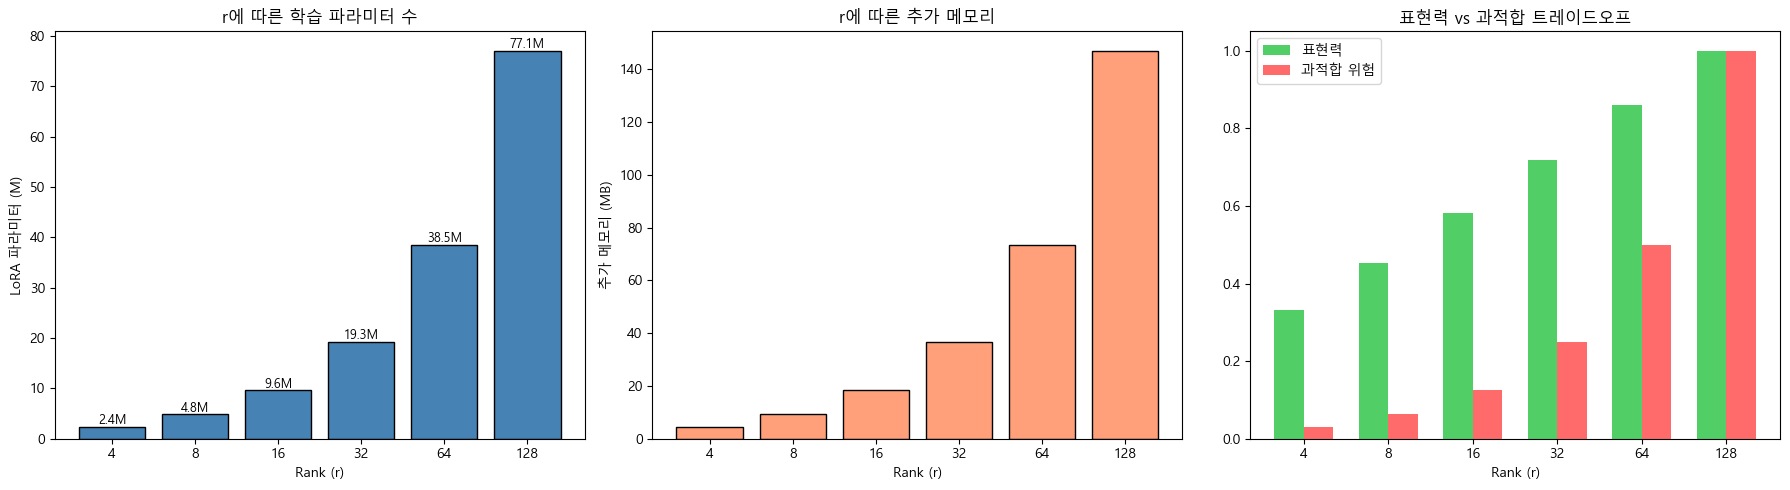

r 선택 가이드:
  r=8:   간단한 태스크 (감성분석, 분류)
  r=16:  범용 파인튜닝 (instruction following)
  r=32:  구조적 출력 (SQL, 코드 생성)
  r=64:  복잡한 추론 (수학, 논리)
  r=128: 거의 Full FT에 가까움 (보통 불필요)


In [4]:
# === r (rank) 변화에 따른 영향 시뮬레이션 ===
# 실제 학습 없이 파라미터 수와 이론적 영향을 분석

hidden_size = 1536  # Qwen 2.5 1.5B의 hidden_size
num_layers = 28
num_targets = 7  # q,k,v,o,gate,up,down

ranks = [4, 8, 16, 32, 64, 128]
params_list = []
memory_list = []

for r in ranks:
    # 대략적 계산: 각 target에 (in+out)×r 파라미터
    total_lora = num_layers * num_targets * 2 * hidden_size * r
    memory_mb = total_lora * 2 / (1024**2)  # fp16
    params_list.append(total_lora)
    memory_list.append(memory_mb)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1) 파라미터 수
axes[0].bar([str(r) for r in ranks], [p/1e6 for p in params_list], 
           color='steelblue', edgecolor='black')
axes[0].set_xlabel('Rank (r)')
axes[0].set_ylabel('LoRA 파라미터 (M)')
axes[0].set_title('r에 따른 학습 파라미터 수')
for i, p in enumerate(params_list):
    axes[0].text(i, p/1e6 + 0.5, f'{p/1e6:.1f}M', ha='center', fontsize=9)

# 2) 메모리 추가 사용량
axes[1].bar([str(r) for r in ranks], memory_list,
           color='#ffa07a', edgecolor='black')
axes[1].set_xlabel('Rank (r)')
axes[1].set_ylabel('추가 메모리 (MB)')
axes[1].set_title('r에 따른 추가 메모리')

# 3) 이론적 표현력 vs 과적합 트레이드오프
expressiveness = [np.log2(r+1) / np.log2(129) for r in ranks]  # 정규화된 표현력
overfit_risk = [r/128 for r in ranks]  # 과적합 위험도

x = np.arange(len(ranks))
width = 0.35
axes[2].bar(x - width/2, expressiveness, width, label='표현력', color='#51cf66')
axes[2].bar(x + width/2, overfit_risk, width, label='과적합 위험', color='#ff6b6b')
axes[2].set_xlabel('Rank (r)')
axes[2].set_xticks(x)
axes[2].set_xticklabels([str(r) for r in ranks])
axes[2].set_title('표현력 vs 과적합 트레이드오프')
axes[2].legend()

plt.tight_layout()
plt.show()

print("r 선택 가이드:")
print("  r=8:   간단한 태스크 (감성분석, 분류)")
print("  r=16:  범용 파인튜닝 (instruction following)")
print("  r=32:  구조적 출력 (SQL, 코드 생성)")
print("  r=64:  복잡한 추론 (수학, 논리)")
print("  r=128: 거의 Full FT에 가까움 (보통 불필요)")

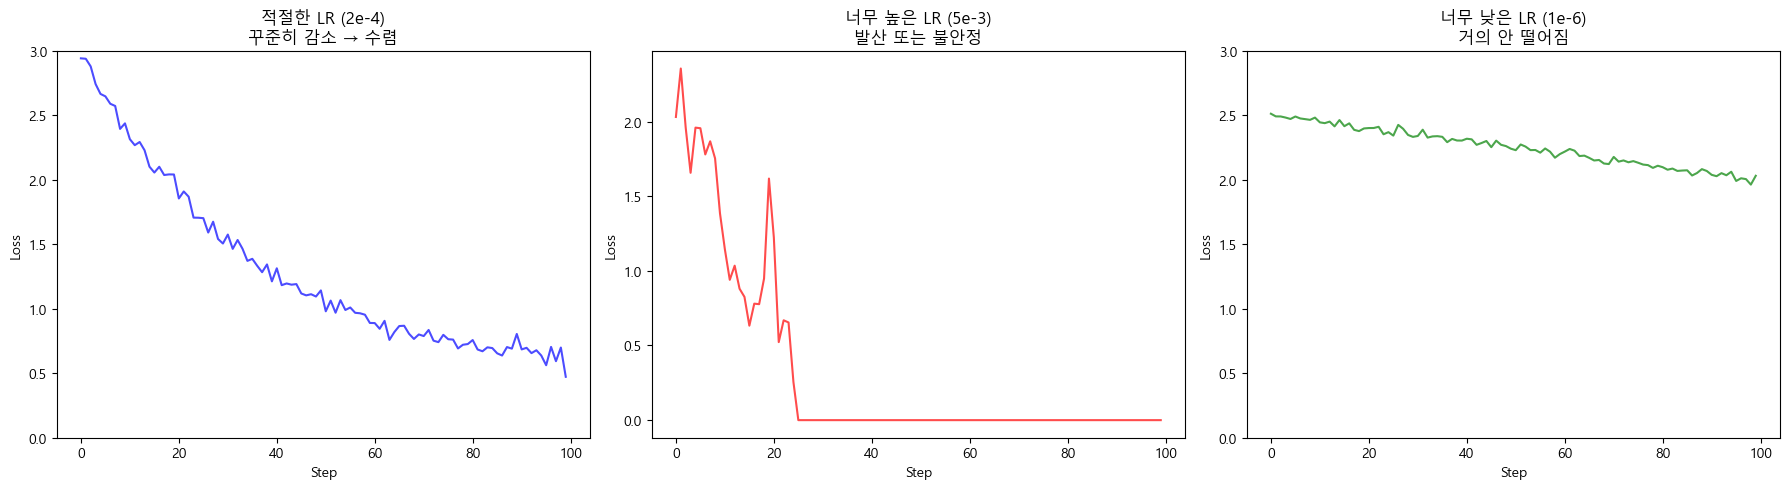

Learning Rate 진단:
  1. Loss가 안 떨어짐 → lr 10배 올리기
  2. Loss가 NaN/발산 → lr 10배 내리기
  3. Loss가 초반만 떨어짐 → lr은 ok, 데이터/모델 문제
  4. 초반 급감 후 서서히 수렴 → 이상적 패턴

LoRA 권장 범위: 1e-5 ~ 5e-4
  - 보수적: 5e-5
  - 표준:   2e-4
  - 공격적: 5e-4


In [5]:
# === Learning Rate 선택 가이드 ===

# 학습률별 전형적인 Loss 패턴 시뮬레이션
steps = np.arange(0, 100)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 적절한 lr
loss_good = 2.5 * np.exp(-0.03 * steps) + 0.5 + np.random.randn(100) * 0.05
axes[0].plot(steps, loss_good, 'b-', alpha=0.7)
axes[0].set_title('적절한 LR (2e-4)\n꾸준히 감소 → 수렴')
axes[0].set_xlabel('Step')
axes[0].set_ylabel('Loss')
axes[0].set_ylim(0, 3)

# 너무 높은 lr
loss_high = 2.5 + np.cumsum(np.random.randn(100) * 0.3)
loss_high = np.clip(loss_high, 0, 10)
axes[1].plot(steps, loss_high, 'r-', alpha=0.7)
axes[1].set_title('너무 높은 LR (5e-3)\n발산 또는 불안정')
axes[1].set_xlabel('Step')
axes[1].set_ylabel('Loss')

# 너무 낮은 lr
loss_low = 2.5 - 0.005 * steps + np.random.randn(100) * 0.02
axes[2].plot(steps, loss_low, 'g-', alpha=0.7)
axes[2].set_title('너무 낮은 LR (1e-6)\n거의 안 떨어짐')
axes[2].set_xlabel('Step')
axes[2].set_ylabel('Loss')
axes[2].set_ylim(0, 3)

plt.tight_layout()
plt.show()

print("Learning Rate 진단:")
print("  1. Loss가 안 떨어짐 → lr 10배 올리기")
print("  2. Loss가 NaN/발산 → lr 10배 내리기")
print("  3. Loss가 초반만 떨어짐 → lr은 ok, 데이터/모델 문제")
print("  4. 초반 급감 후 서서히 수렴 → 이상적 패턴")
print("\nLoRA 권장 범위: 1e-5 ~ 5e-4")
print("  - 보수적: 5e-5")
print("  - 표준:   2e-4")
print("  - 공격적: 5e-4")

---
## 2. 과적합 진단과 대응

파인튜닝에서 가장 빈번한 문제. Train Loss는 떨어지는데 Eval Loss가 올라가는 현상.

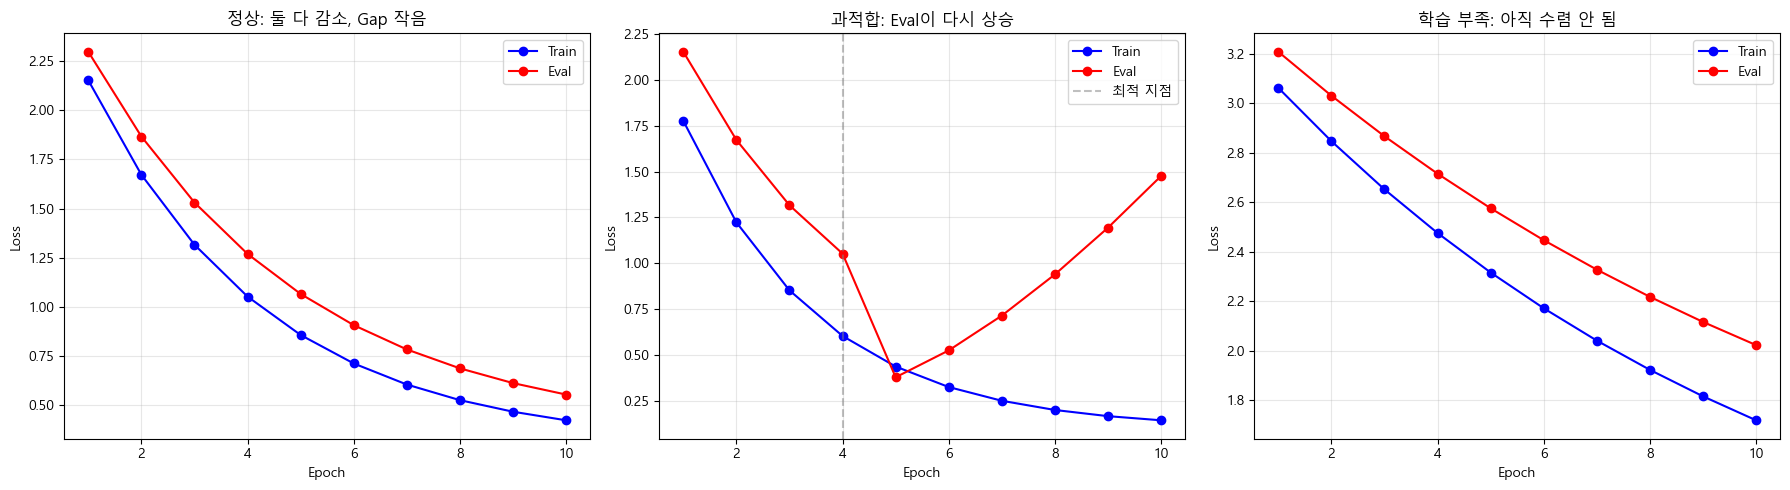

과적합 대응 전략:
  1. Epoch 줄이기 (가장 간단, 가장 효과적)
  2. 데이터 늘리기 (근본적 해결)
  3. r 줄이기 (LoRA 용량 축소)
  4. dropout 올리기 (0.05 → 0.1)
  5. weight decay 추가 (0.01~0.1)
  6. Early stopping (eval loss 모니터링)


In [6]:
# === 과적합 패턴 시뮬레이션 및 진단 ===

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
epochs = np.arange(1, 11)

# 1) 정상 수렴
train_normal = 2.5 * np.exp(-0.3 * epochs) + 0.3
eval_normal = 2.5 * np.exp(-0.25 * epochs) + 0.35
axes[0].plot(epochs, train_normal, 'b-o', label='Train')
axes[0].plot(epochs, eval_normal, 'r-o', label='Eval')
axes[0].set_title('정상: 둘 다 감소, Gap 작음')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 2) 과적합
train_overfit = 2.5 * np.exp(-0.4 * epochs) + 0.1
eval_overfit = np.concatenate([
    2.5 * np.exp(-0.3 * epochs[:4]) + 0.3,
    0.3 + 0.08 * (epochs[4:] - 4)**1.5
])
axes[1].plot(epochs, train_overfit, 'b-o', label='Train')
axes[1].plot(epochs, eval_overfit, 'r-o', label='Eval')
axes[1].axvline(x=4, color='gray', linestyle='--', alpha=0.5, label='최적 지점')
axes[1].set_title('과적합: Eval이 다시 상승')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# 3) 학습 부족
train_under = 2.5 * np.exp(-0.1 * epochs) + 0.8
eval_under = 2.5 * np.exp(-0.08 * epochs) + 0.9
axes[2].plot(epochs, train_under, 'b-o', label='Train')
axes[2].plot(epochs, eval_under, 'r-o', label='Eval')
axes[2].set_title('학습 부족: 아직 수렴 안 됨')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Loss')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("과적합 대응 전략:")
print("=" * 50)
print("  1. Epoch 줄이기 (가장 간단, 가장 효과적)")
print("  2. 데이터 늘리기 (근본적 해결)")
print("  3. r 줄이기 (LoRA 용량 축소)")
print("  4. dropout 올리기 (0.05 → 0.1)")
print("  5. weight decay 추가 (0.01~0.1)")
print("  6. Early stopping (eval loss 모니터링)")

---
## 3. Unsloth: 학습 속도 2배 향상

같은 모델, 같은 데이터인데 **2배 빠르고 70% 적은 메모리**를 쓴다.  
커널 레벨 최적화로 달성.

In [7]:
# === Unsloth 설정 코드 ===
# Unsloth는 별도 설치 필요: pip install unsloth
# 여기서는 코드 구조를 보여주고, 실행은 Colab/Linux 환경 권장

print("Unsloth 파인튜닝 코드:")
print("=" * 60)
print("""
# pip install unsloth
from unsloth import FastLanguageModel

# 1. 모델 로드 (Unsloth가 자동으로 4-bit 양자화 + 최적화)
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "Qwen/Qwen2.5-7B-Instruct",
    max_seq_length = 2048,
    dtype = None,            # 자동 감지
    load_in_4bit = True,     # QLoRA
)

# 2. LoRA 적용 (Unsloth 최적화 버전)
model = FastLanguageModel.get_peft_model(
    model,
    r = 16,
    lora_alpha = 32,
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj",
                      "gate_proj", "up_proj", "down_proj"],
    lora_dropout = 0,         # Unsloth 권장: 0 (자체 최적화)
    bias = "none",
    use_gradient_checkpointing = "unsloth",  # 핵심: Unsloth 전용 체크포인팅
)

# 3. 학습 (TRL SFTTrainer와 동일하게 사용)
from trl import SFTTrainer, SFTConfig

trainer = SFTTrainer(
    model = model,
    processing_class = tokenizer,
    train_dataset = train_data,
    args = SFTConfig(
        per_device_train_batch_size = 4,  # Unsloth는 배치 더 키울 수 있음
        gradient_accumulation_steps = 4,
        num_train_epochs = 3,
        learning_rate = 2e-4,
        fp16 = not torch.cuda.is_bf16_supported(),
        bf16 = torch.cuda.is_bf16_supported(),
        max_length = 2048,
        dataset_text_field = "text",
        output_dir = "./output/unsloth_run",
    ),
)

trainer.train()

# 4. 다양한 형식으로 저장
model.save_pretrained_gguf("model-gguf", tokenizer)      # llama.cpp용
model.save_pretrained_merged("model-merged", tokenizer)   # 병합 저장
model.push_to_hub("my-username/my-model", tokenizer)      # HuggingFace 업로드
""")

print("Unsloth vs 일반 HuggingFace:")
print(f"{'항목':<20} {'HuggingFace':<15} {'Unsloth':<15}")
print("-" * 50)
print(f"{'학습 속도':<20} {'1x':<15} {'2x':<15}")
print(f"{'메모리 사용':<20} {'100%':<15} {'30%':<15}")
print(f"{'Qwen 7B 최소 VRAM':<20} {'~20GB':<15} {'~9GB':<15}")
print(f"{'GGUF 변환':<20} {'별도 도구':<15} {'내장':<15}")
print(f"{'API 호환성':<20} {'표준':<15} {'표준 (TRL 호환)':<15}")

Unsloth 파인튜닝 코드:

# pip install unsloth
from unsloth import FastLanguageModel

# 1. 모델 로드 (Unsloth가 자동으로 4-bit 양자화 + 최적화)
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "Qwen/Qwen2.5-7B-Instruct",
    max_seq_length = 2048,
    dtype = None,            # 자동 감지
    load_in_4bit = True,     # QLoRA
)

# 2. LoRA 적용 (Unsloth 최적화 버전)
model = FastLanguageModel.get_peft_model(
    model,
    r = 16,
    lora_alpha = 32,
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj",
                      "gate_proj", "up_proj", "down_proj"],
    lora_dropout = 0,         # Unsloth 권장: 0 (자체 최적화)
    bias = "none",
    use_gradient_checkpointing = "unsloth",  # 핵심: Unsloth 전용 체크포인팅
)

# 3. 학습 (TRL SFTTrainer와 동일하게 사용)
from trl import SFTTrainer, SFTConfig

trainer = SFTTrainer(
    model = model,
    processing_class = tokenizer,
    train_dataset = train_data,
    args = SFTConfig(
        per_device_train_batch_size = 4,  # Unsloth는 배치 더 키울 수 있음
        gradient_accumul

---
## 4. HuggingFace Hub 업로드

학습한 모델을 공유하여 재사용 가능하게 만든다.

In [8]:
# === HuggingFace Hub 업로드 방법 ===

print("HuggingFace Hub 업로드 절차:")
print("=" * 60)
print("""
1. 토큰 발급
   - https://huggingface.co/settings/tokens 에서 Write 권한 토큰 생성

2. 로그인
   from huggingface_hub import login
   login(token="hf_YOUR_TOKEN")

3-A. LoRA 어댑터만 업로드 (권장)
   peft_model.push_to_hub("username/model-name-lora")
   tokenizer.push_to_hub("username/model-name-lora")
   -> 수 MB, 빠른 업로드
   -> 사용자가 원본 모델 + 어댑터를 합쳐서 사용

3-B. 병합된 전체 모델 업로드
   merged = peft_model.merge_and_unload()
   merged.push_to_hub("username/model-name")
   tokenizer.push_to_hub("username/model-name")
   -> 수 GB, 사용이 편리

4. 모델 카드 작성 (README.md)
   - 베이스 모델, 학습 데이터, 하이퍼파라미터, 성능 기록
""")

HuggingFace Hub 업로드 절차:

1. 토큰 발급
   - https://huggingface.co/settings/tokens 에서 Write 권한 토큰 생성

2. 로그인
   from huggingface_hub import login
   login(token="hf_YOUR_TOKEN")

3-A. LoRA 어댑터만 업로드 (권장)
   peft_model.push_to_hub("username/model-name-lora")
   tokenizer.push_to_hub("username/model-name-lora")
   -> 수 MB, 빠른 업로드
   -> 사용자가 원본 모델 + 어댑터를 합쳐서 사용

3-B. 병합된 전체 모델 업로드
   merged = peft_model.merge_and_unload()
   merged.push_to_hub("username/model-name")
   tokenizer.push_to_hub("username/model-name")
   -> 수 GB, 사용이 편리

4. 모델 카드 작성 (README.md)
   - 베이스 모델, 학습 데이터, 하이퍼파라미터, 성능 기록



In [9]:
# === 모델 카드 (README.md) 템플릿 생성 ===

model_card_template = """
---
license: apache-2.0
base_model: Qwen/Qwen2.5-1.5B-Instruct
tags:
  - text-to-sql
  - lora
  - qlora
  - fine-tuning
---

# Text-to-SQL LoRA Adapter

## Model Description
자연어 질문을 SQL 쿼리로 변환하는 LoRA 어댑터입니다.

## Training Details

| Parameter | Value |
|-----------|-------|
| Base Model | Qwen/Qwen2.5-1.5B-Instruct |
| Method | QLoRA (4-bit NF4) |
| LoRA Rank | 32 |
| LoRA Alpha | 64 |
| Learning Rate | 2e-4 |
| Epochs | 3 |
| Train Data | b-mc2/sql-create-context (3000 samples) |
| Max Seq Length | 512 |

## Usage

```python
from peft import PeftModel
from transformers import AutoModelForCausalLM, AutoTokenizer

base = AutoModelForCausalLM.from_pretrained("Qwen/Qwen2.5-1.5B-Instruct")
model = PeftModel.from_pretrained(base, "username/text-to-sql-lora")
tokenizer = AutoTokenizer.from_pretrained("username/text-to-sql-lora")
```

## Limitations
- 3000개 샘플로 학습하여 복잡한 SQL (서브쿼리, 다중 JOIN)은 부정확할 수 있음
- 영어 질문에 최적화, 한국어는 추가 학습 필요
"""

print("모델 카드 템플릿:")
print("=" * 60)
print(model_card_template)

모델 카드 템플릿:

---
license: apache-2.0
base_model: Qwen/Qwen2.5-1.5B-Instruct
tags:
  - text-to-sql
  - lora
  - qlora
  - fine-tuning
---

# Text-to-SQL LoRA Adapter

## Model Description
자연어 질문을 SQL 쿼리로 변환하는 LoRA 어댑터입니다.

## Training Details

| Parameter | Value |
|-----------|-------|
| Base Model | Qwen/Qwen2.5-1.5B-Instruct |
| Method | QLoRA (4-bit NF4) |
| LoRA Rank | 32 |
| LoRA Alpha | 64 |
| Learning Rate | 2e-4 |
| Epochs | 3 |
| Train Data | b-mc2/sql-create-context (3000 samples) |
| Max Seq Length | 512 |

## Usage

```python
from peft import PeftModel
from transformers import AutoModelForCausalLM, AutoTokenizer

base = AutoModelForCausalLM.from_pretrained("Qwen/Qwen2.5-1.5B-Instruct")
model = PeftModel.from_pretrained(base, "username/text-to-sql-lora")
tokenizer = AutoTokenizer.from_pretrained("username/text-to-sql-lora")
```

## Limitations
- 3000개 샘플로 학습하여 복잡한 SQL (서브쿼리, 다중 JOIN)은 부정확할 수 있음
- 영어 질문에 최적화, 한국어는 추가 학습 필요



---
## 5. 실험 기록 관리

여러 실험을 체계적으로 기록하지 않으면 나중에 "그때 뭐가 좋았더라?"를 반복한다.

In [10]:
# === 실험 기록 시스템 ===
# W&B(Weights & Biases) 없이도 쓸 수 있는 간단한 기록 방식

class ExperimentTracker:
    """실험 결과를 JSON으로 기록하고 비교하는 간단한 트래커"""
    
    def __init__(self, save_path="./experiments.json"):
        self.save_path = save_path
        self.experiments = []
        if os.path.exists(save_path):
            with open(save_path) as f:
                self.experiments = json.load(f)
    
    def log(self, name, config, metrics, notes=""):
        """실험 결과 기록"""
        record = {
            "name": name,
            "timestamp": datetime.now().isoformat(),
            "config": config,
            "metrics": metrics,
            "notes": notes,
        }
        self.experiments.append(record)
        
        with open(self.save_path, 'w') as f:
            json.dump(self.experiments, f, indent=2, ensure_ascii=False)
        
        print(f"실험 '{name}' 기록 완료")
    
    def compare(self):
        """모든 실험 결과 비교"""
        if not self.experiments:
            print("기록된 실험이 없습니다.")
            return
        
        print(f"{'이름':<16} {'r':>4} {'lr':>10} {'최종Loss':>10} {'EvalLoss':>10}")
        print("-" * 55)
        for exp in self.experiments:
            c = exp['config']
            m = exp['metrics']
            print(f"{exp['name']:<16} {c.get('r',''):>4} {c.get('lr',''):>10} "
                  f"{m.get('final_train_loss',''):>10} {m.get('final_eval_loss',''):>10}")

# 사용 예시 (시뮬레이션)
tracker = ExperimentTracker("./output/experiments.json")

# 가상의 실험 결과 기록
tracker.log(
    name="baseline_r16",
    config={"r": 16, "alpha": 32, "lr": "2e-4", "epochs": 3, "model": "Qwen2.5-1.5B"},
    metrics={"final_train_loss": "0.85", "final_eval_loss": "0.92", "steps": 90},
    notes="첫 번째 실행. 정상 수렴."
)

tracker.log(
    name="sql_r32",
    config={"r": 32, "alpha": 64, "lr": "2e-4", "epochs": 3, "model": "Qwen2.5-1.5B"},
    metrics={"final_train_loss": "0.72", "final_eval_loss": "0.88", "steps": 90},
    notes="Text-to-SQL 프로젝트. r=32로 올려서 SQL 정확도 향상."
)

print("\n실험 비교:")
tracker.compare()

print("\n실전 팁:")
print("  - 프로젝트 규모가 커지면 W&B(wandb.ai) 사용 권장")
print("  - report_to='wandb'만 추가하면 자동 로깅")
print("  - 무료 플랜으로 충분히 사용 가능")

실험 'baseline_r16' 기록 완료
실험 'sql_r32' 기록 완료

실험 비교:
이름                  r         lr     최종Loss   EvalLoss
-------------------------------------------------------
baseline_r16       16       2e-4       0.85       0.92
sql_r32            32       2e-4       0.72       0.88

실전 팁:
  - 프로젝트 규모가 커지면 W&B(wandb.ai) 사용 권장
  - report_to='wandb'만 추가하면 자동 로깅
  - 무료 플랜으로 충분히 사용 가능


---
## 6. 트러블슈팅 체크리스트

Phase 5(트러블슈팅)의 핵심을 미리 정리.

In [11]:
# === 파인튜닝 트러블슈팅 체크리스트 ===

print("파인튜닝 트러블슈팅 체크리스트:")
print("=" * 60)

issues = [
    {
        "symptom": "OOM (Out of Memory)",
        "solutions": [
            "per_device_train_batch_size 줄이기 (4→2→1)",
            "gradient_accumulation_steps 올리기 (실효 배치 유지)",
            "max_seq_length 줄이기 (2048→1024→512)",
            "gradient_checkpointing=True",
            "r 줄이기 (32→16→8)",
            "QLoRA 4-bit로 전환",
        ]
    },
    {
        "symptom": "Loss가 안 떨어짐",
        "solutions": [
            "learning_rate 10배 올리기",
            "데이터 형식 확인 (ChatML이 맞는지)",
            "tokenizer.pad_token 설정 확인",
            "데이터가 실제로 로드되는지 확인",
        ]
    },
    {
        "symptom": "Loss가 NaN",
        "solutions": [
            "learning_rate 10배 낮추기",
            "max_grad_norm=1.0 설정",
            "bf16 대신 fp16 시도 (또는 반대)",
            "데이터에 빈 문자열/None이 있는지 확인",
        ]
    },
    {
        "symptom": "학습 후 모델이 이상한 출력",
        "solutions": [
            "Chat Template 형식이 모델과 맞는지 확인",
            "과적합 여부 확인 (epoch 줄이기)",
            "데이터 품질 재검토 (Phase 3 파이프라인)",
            "생성 시 do_sample=False로 greedy 테스트",
        ]
    },
    {
        "symptom": "학습이 너무 느림",
        "solutions": [
            "Unsloth 사용 (2배 가속)",
            "max_seq_length 줄이기",
            "데이터 수 줄이기 (먼저 소량으로 검증)",
            "gradient_checkpointing=True (속도 약간 감소, 메모리 절약)",
        ]
    },
]

for issue in issues:
    print(f"\n  [{issue['symptom']}]")
    for j, sol in enumerate(issue['solutions'], 1):
        print(f"    {j}. {sol}")

파인튜닝 트러블슈팅 체크리스트:

  [OOM (Out of Memory)]
    1. per_device_train_batch_size 줄이기 (4→2→1)
    2. gradient_accumulation_steps 올리기 (실효 배치 유지)
    3. max_seq_length 줄이기 (2048→1024→512)
    4. gradient_checkpointing=True
    5. r 줄이기 (32→16→8)
    6. QLoRA 4-bit로 전환

  [Loss가 안 떨어짐]
    1. learning_rate 10배 올리기
    2. 데이터 형식 확인 (ChatML이 맞는지)
    3. tokenizer.pad_token 설정 확인
    4. 데이터가 실제로 로드되는지 확인

  [Loss가 NaN]
    1. learning_rate 10배 낮추기
    2. max_grad_norm=1.0 설정
    3. bf16 대신 fp16 시도 (또는 반대)
    4. 데이터에 빈 문자열/None이 있는지 확인

  [학습 후 모델이 이상한 출력]
    1. Chat Template 형식이 모델과 맞는지 확인
    2. 과적합 여부 확인 (epoch 줄이기)
    3. 데이터 품질 재검토 (Phase 3 파이프라인)
    4. 생성 시 do_sample=False로 greedy 테스트

  [학습이 너무 느림]
    1. Unsloth 사용 (2배 가속)
    2. max_seq_length 줄이기
    3. 데이터 수 줄이기 (먼저 소량으로 검증)
    4. gradient_checkpointing=True (속도 약간 감소, 메모리 절약)


---
## 7. Phase 4 체크포인트 자가진단

In [12]:
# === Phase 4 체크포인트 ===
# 로드맵에서 요구하는 역량 달성 여부 확인

checkpoints = [
    ("LoRA가 왜 효율적인지 수학적으로 설명할 수 있는가?",
     "01에서 학습: W'=W+BA, d×k → d×r+r×k, r≪min(d,k)"),
    
    ("r, alpha 값을 변경했을 때 어떤 영향이 있는지 아는가?",
     "01+04에서 학습: r↑=표현력↑+과적합위험↑, alpha/r=스케일링"),
    
    ("QLoRA의 4-bit NormalFloat가 무엇인지 설명할 수 있는가?",
     "01에서 학습: 정규분포 기반 비균등 양자화, INT4보다 정밀"),
    
    ("직접 파인튜닝한 모델을 HuggingFace에 업로드했는가?",
     "04에서 학습: push_to_hub() + 모델 카드 작성"),
    
    ("학습 loss 그래프를 해석할 수 있는가?",
     "02+04에서 학습: 수렴/과적합/발산 패턴 진단"),
]

print("Phase 4 체크포인트:")
print("=" * 60)
for i, (question, answer) in enumerate(checkpoints, 1):
    print(f"\n  {i}. {question}")
    print(f"     → {answer}")

print(f"\n{'='*60}")
print("모든 항목에 자신있게 답할 수 있다면 Phase 4 완료.")
print("다음은 Phase 6: 모델 정렬 (DPO) 또는 Phase 5: 트러블슈팅 심화")

Phase 4 체크포인트:

  1. LoRA가 왜 효율적인지 수학적으로 설명할 수 있는가?
     → 01에서 학습: W'=W+BA, d×k → d×r+r×k, r≪min(d,k)

  2. r, alpha 값을 변경했을 때 어떤 영향이 있는지 아는가?
     → 01+04에서 학습: r↑=표현력↑+과적합위험↑, alpha/r=스케일링

  3. QLoRA의 4-bit NormalFloat가 무엇인지 설명할 수 있는가?
     → 01에서 학습: 정규분포 기반 비균등 양자화, INT4보다 정밀

  4. 직접 파인튜닝한 모델을 HuggingFace에 업로드했는가?
     → 04에서 학습: push_to_hub() + 모델 카드 작성

  5. 학습 loss 그래프를 해석할 수 있는가?
     → 02+04에서 학습: 수렴/과적합/발산 패턴 진단

모든 항목에 자신있게 답할 수 있다면 Phase 4 완료.
다음은 Phase 6: 모델 정렬 (DPO) 또는 Phase 5: 트러블슈팅 심화


---
## Phase 4 전체 정리

| # | 내용 | 핵심 |
|---|------|------|
| 01 | LoRA/QLoRA 이론 | W'=W+BA, NF4 양자화, PEFT 라이브러리 |
| 02 | SFT 첫 파인튜닝 | SFTTrainer, 학습→추론→저장 전체 흐름 |
| 03 | Text-to-SQL 프로젝트 | 도메인 특화, r 조정, SQL 평가 |
| 04 | 학습 분석과 최적화 | HP 튜닝, 과적합 진단, Unsloth, Hub 업로드 |

### 핵심 수치 기억

| 항목 | 값 |
|------|----|
| LoRA 학습 비율 | 전체의 ~0.1~1% |
| QLoRA 메모리 절감 | ~75% |
| 표준 learning rate | 2e-4 |
| 표준 alpha/r 비율 | 2 |
| 범용 r | 16 |
| 도메인 특화 r | 32~64 |

### 다음 단계

- **Phase 5**: 학습 트러블슈팅 심화 (Loss 디버깅, 메모리 최적화)
- **Phase 6**: DPO로 모델 정렬 (사람 선호도 반영)